##### Compute the mass of the Earth as a function of radius

Sometimes we need to know the mass below a specified radius inside the Earth. A general definition of the mass $M$ is given by

$$ M = \int_V \rho \, dV $$

When the density is only a function of radius $\rho = \rho(r)$, the volume element becomes

$$ dV = 4\pi r^2 dr $$

so the mass $M(r)$ from the center $r=0$ to the specified radius $r$ is

$$ M(r) = 4\pi \int_0^r r'^2 \rho(r') dr' $$

where $r$ is radius of interest and $r'$ is the integration variable. The total mass of the Earth is $M(a)$ where $a$ is the radius of the Earth.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Load the PREM Earthmodel

In [2]:
data = np.loadtxt('./PREM_EarthModel.txt',skiprows=1)
r = data[:,0]
rho = data[:,1]

Let's plot the input data

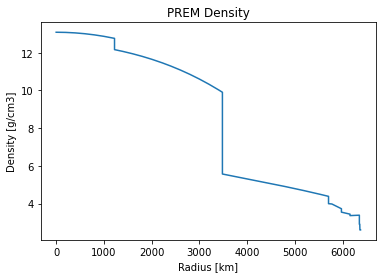

In [3]:
fig = plt.figure()
ax = plt.axes()
ax.plot(r,rho)
plt.title("PREM Density")
plt.xlabel("Radius [km]")
plt.ylabel("Density [g/cm3]");

Define a function to evaluate integral for mass $M(r)$. The input arguments are $r$ in km and $\rho$ in g/cm$^3$

In [4]:
def Mass(r,rho):


# convert to meters and kg
    rm = r * 1.0e3
    rhokg = rho * 1.0e3

# Integrate using trapezoid rule
    n = len(rm)
    m = np.zeros(n)
    for k in range(n-1):
        mean_rho = 0.5 * (rhokg[k] + rhokg[k+1])
        mean_r2 = 0.5 * (rm[k]**2 + rm[k+1]**2)
        m[k+1] = m[k] + (rm[k+1]-rm[k]) * (4 * np.pi) * mean_rho * mean_r2
        
    return m

Call function to evaluate mass

In [5]:
m = Mass(r,rho)
print("The computed mass of the Earth is {:.4e} kg".format(m[-1]))

The computed mass of the Earth is 5.9766e+24 kg


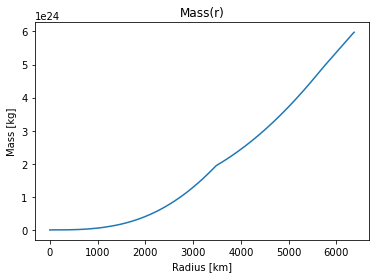

In [6]:
fig = plt.figure()
ax = plt.axes()
ax.plot(r,m)
plt.title("Mass(r)")
plt.xlabel("Radius [km]")
plt.ylabel("Mass [kg]");